In [8]:
# data imports -> ! run once per runtime
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# tf.keras.utils.get_file with extract=True is expected to return the path to the extracted directory.
# We will directly assign this return value to data_dir.
data_dir = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir)

# The flower_photos dataset typically extracts into a top-level directory
# which itself contains another directory named 'flower_photos' that holds the category subdirectories.
# We adjust data_dir to point to this nested directory if it exists.
if (data_dir / 'flower_photos').is_dir():
    data_dir = data_dir / 'flower_photos'

# After this, data_dir should point to the directory containing 'daisy', 'dandelion', etc.

In [33]:
# other necessary imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from tqdm import tqdm

In [15]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)
print(os.listdir(data_dir))

3670
['LICENSE.txt', 'sunflowers', 'daisy', 'dandelion', 'roses', 'tulips']


In [47]:
roses = list(data_dir.glob('roses/*'))
print(len(roses))
PIL.Image.open(str(roses[2]))
image = PIL.Image.open(str(roses[3]))
image = np.array(image)
image.shape

# => initial image shape:

641


(240, 320, 3)

In [18]:

import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define transformations for the images
# For example, resize all images to 224x224 and convert them to tensors.
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize
])

# Create the dataset using ImageFolder
# data_dir should be the path to your 'flower_photos' directory containing 'roses', 'daisy', etc.
full_dataset = torchvision.datasets.ImageFolder(
    root=data_dir,
    transform=transform
)

print(f"Number of images in the dataset: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")

Number of images in the dataset: 3670
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [19]:
# To prepare for training, you'd typically split this into training and validation sets.
# For now, let's create a DataLoader for the full dataset.
batch_size = 32 # You can adjust this

# Create a DataLoader
data_loader = DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffle the data for training
    num_workers=2 # Number of subprocesses to use for data loading
)


In [22]:
from sklearn.model_selection import train_test_split

# Get the targets (labels) from the full_dataset
targets = full_dataset.targets

# Get indices for stratified split
train_indices, test_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.2, # 20% for test set
    stratify=targets, # Stratify by targets to ensure class balance
    random_state=42 # for reproducibility
)

# Create Subset datasets using the indices
from torch.utils.data import Subset

train_dataset_stratified = Subset(full_dataset, train_indices)
test_dataset_stratified = Subset(full_dataset, test_indices)

print(f"Stratified Training dataset size: {len(train_dataset_stratified)}")
print(f"Stratified Test dataset size: {len(test_dataset_stratified)}")

# Create DataLoaders for the stratified train and test sets
train_loader_stratified = DataLoader(
    train_dataset_stratified,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader_stratified = DataLoader(
    test_dataset_stratified,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print(f"Number of batches in stratified train_loader: {len(train_loader_stratified)}")
print(f"Number of batches in stratified test_loader: {len(test_loader_stratified)}")

Stratified Training dataset size: 2936
Stratified Test dataset size: 734
Number of batches in stratified train_loader: 92
Number of batches in stratified test_loader: 23


Class distribution in Training Dataset:
roses: 513 samples
dandelion: 719 samples
daisy: 506 samples
sunflowers: 559 samples
tulips: 639 samples


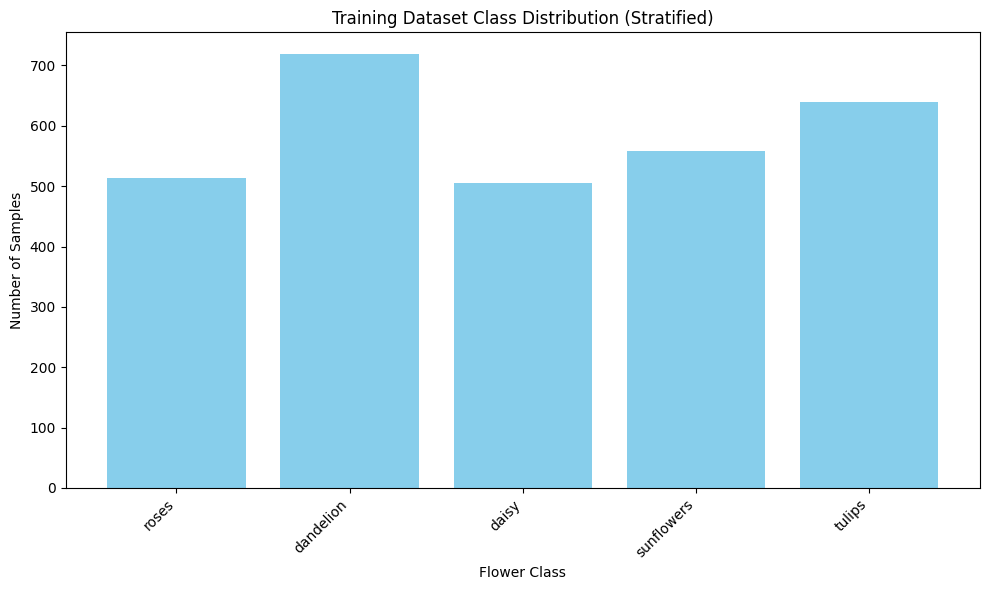

In [23]:
import collections
import matplotlib.pyplot as plt

# Get the class labels for the training dataset
train_labels = [full_dataset.targets[i] for i in train_dataset_stratified.indices]

# Count the occurrences of each class
class_counts = collections.Counter(train_labels)

# Get the class names from the original full_dataset
class_names = full_dataset.classes

# Prepare data for plotting
labels = [class_names[label] for label in class_counts.keys()]
counts = list(class_counts.values())

print("Class distribution in Training Dataset:")
for label, count in zip(labels, counts):
    print(f"{label}: {count} samples")

# Plotting the distribution
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
plt.xlabel('Flower Class')
plt.ylabel('Number of Samples')
plt.title('Training Dataset Class Distribution (Stratified)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()
        # initial image shape after transform: 224:244
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        # image shape after conv: 224:224
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # image shape after pooling: 224/2:224/2 => 112:112
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        # image shape after conv: 112:112
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # image shape after pooling: 112/2:112/2 => 56:56
        self.fc1 = nn.Linear(16 * 56 * 56, num_classes)
        # 16 channels * 56 height * 56 width

    def forward(self, x):
       x = F.relu(self.conv1(x))
       x = self.pool(x)
       x = F.relu(self.conv2(x))
       x = self.pool(x)
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)
       return x

# if cuda is available use gpu else cpu

device = "cpu"

model = Net(in_channels=3, num_classes=5)

In [49]:
print(model)

Net(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=50176, out_features=5, bias=True)
)


In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [51]:
num_epochs=10
for epoch in range(num_epochs):
 # Iterate over training batches
   print(f"Epoch [{epoch + 1}/{num_epochs}]")

   for batch_index, (data, targets) in enumerate(tqdm(train_loader_stratified)):
       data = data.to(device)
       targets = targets.to(device)
       scores = model(data)
       loss = criterion(scores, targets)
       optimizer.zero_grad()
       loss.backward()
       optimizer.step()

Epoch [1/10]


100%|██████████| 92/92 [00:50<00:00,  1.83it/s]


Epoch [2/10]


100%|██████████| 92/92 [00:49<00:00,  1.84it/s]


Epoch [3/10]


...

100%|██████████| 92/92 [00:47<00:00,  1.94it/s]


Epoch [9/10]


100%|██████████| 92/92 [00:48<00:00,  1.89it/s]


Epoch [10/10]


100%|██████████| 92/92 [00:48<00:00,  1.89it/s]


In [53]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 29.8 MB/s eta 0:00:00


In [54]:
from torchmetrics import Accuracy, F1Score

# Initialize metrics
# num_classes should be 5 for your flower dataset
acc_metric = Accuracy(task="multiclass", num_classes=5).to(device)
f1_metric = F1Score(task="multiclass", num_classes=5, average='macro').to(device) # 'macro' for Macro F1

# Iterate over the dataset batches
model.eval() # Set model to evaluation mode
with torch.no_grad(): # Disable gradient calculations
   for images, labels in test_loader_stratified: # Use the stratified test loader
       images = images.to(device)
       labels = labels.to(device)

       # Get predicted probabilities for test data batch
       outputs = model(images)
       _, preds = torch.max(outputs, 1)

       # Update metrics
       acc_metric.update(preds, labels)
       f1_metric.update(preds, labels)

# Compute and print total test metrics
test_accuracy = acc_metric.compute()
test_macro_f1 = f1_metric.compute()

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1 Score: {test_macro_f1:.4f}")

Test Accuracy: 0.5368
Test Macro F1 Score: 0.5033
